In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'C:\Users\User\PyCharmMiscProject\Datasets\student_placement_synthetic.csv')
print(df.columns)
print(df.shape)


Index(['branch', 'college_tier', 'cgpa', 'backlogs', 'coding_skills',
       'dsa_score', 'aptitude_score', 'communication_skills', 'ml_knowledge',
       'system_design', 'internships', 'projects_count', 'certifications',
       'hackathons', 'open_source_contributions', 'extracurriculars',
       'placement_status', 'salary_package_lpa'],
      dtype='object')
(100000, 18)


In [128]:
print(df.dtypes)

branch                        object
college_tier                  object
cgpa                         float64
backlogs                       int64
coding_skills                float64
dsa_score                    float64
aptitude_score               float64
communication_skills         float64
ml_knowledge                 float64
system_design                float64
internships                    int64
projects_count                 int64
certifications                 int64
hackathons                     int64
open_source_contributions      int64
extracurriculars               int64
placement_status               int64
salary_package_lpa           float64
dtype: object


In [98]:
df.isna().sum()

branch                           0
college_tier                     0
cgpa                             0
backlogs                         0
coding_skills                    0
dsa_score                        0
aptitude_score                   0
communication_skills             0
ml_knowledge                     0
system_design                    0
internships                      0
projects_count                   0
certifications                   0
hackathons                       0
open_source_contributions        0
extracurriculars                 0
placement_status                 0
salary_package_lpa           31525
dtype: int64

In [16]:
x = df.drop(["placement_status", "salary_package_lpa"], axis=1)
x

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,IT,Tier-3,6.08,0,3.1,5.4,67.4,4.3,9.1,3.8,2,3,2,0,0,3
99996,IT,Tier-3,7.46,0,4.8,6.8,59.5,7.6,5.6,2.4,1,2,3,0,1,0
99997,EE,Tier-2,7.94,0,4.9,9.1,55.1,6.1,3.5,5.2,0,2,1,0,1,2
99998,ME,Tier-3,6.63,0,5.0,8.0,65.0,5.7,6.2,0.2,1,4,2,0,0,1


<Axes: xlabel='placement_status', ylabel='count'>

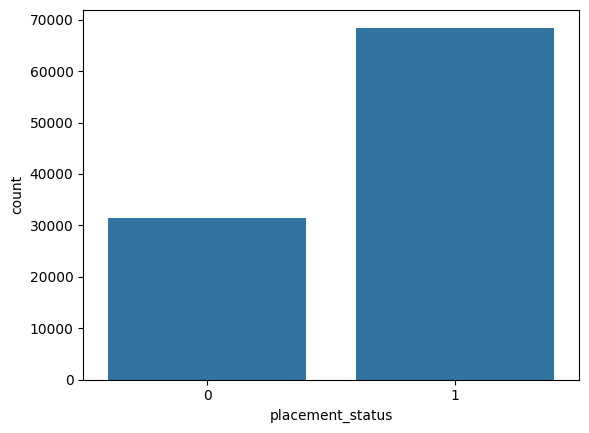

In [131]:
sns.countplot(x=df["placement_status"])

<Axes: xlabel='placement_status', ylabel='cgpa'>

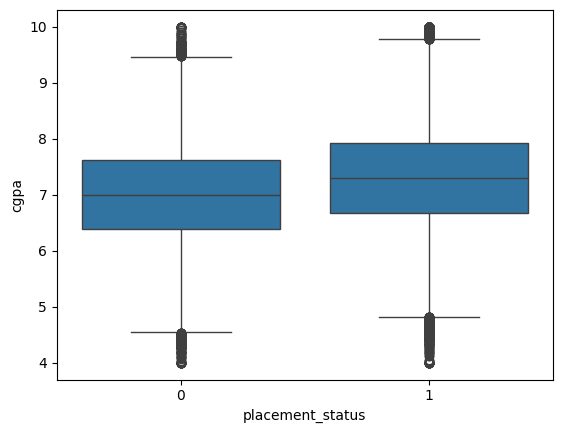

In [132]:
sns.boxplot(x="placement_status", y="cgpa", data=df)

<Axes: xlabel='placement_status', ylabel='internships'>

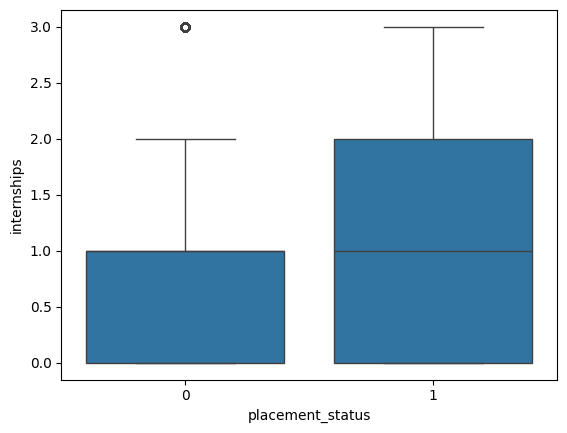

In [133]:
sns.boxplot(x="placement_status", y="internships", data=df)

<Axes: xlabel='placement_status', ylabel='coding_skills'>

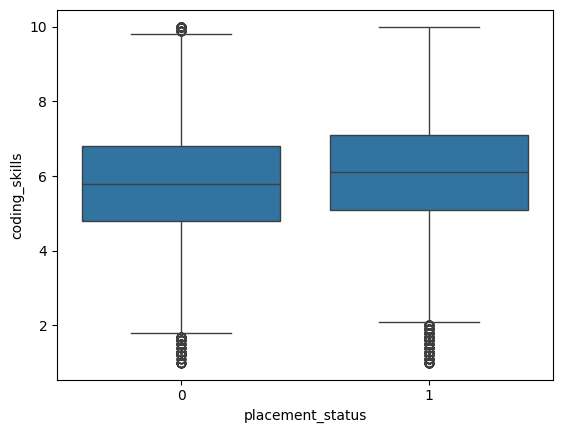

In [134]:
sns.boxplot(x="placement_status", y="coding_skills", data=df)

In [136]:
df["technical_skill_score"] = (
    df["coding_skills"] +
    df["dsa_score"] +
    df["ml_knowledge"] +
    df["system_design"]
) / 4

df["technical_skill_score"]

0        4.675
1        5.375
2        5.500
3        4.025
4        4.025
         ...  
99995    5.350
99996    4.900
99997    5.675
99998    4.850
99999    4.300
Name: technical_skill_score, Length: 100000, dtype: float64

In [137]:
df["experience_score"] = (
    df["internships"] +
    df["projects_count"] +
    df["hackathons"] +
    df["open_source_contributions"]
)

In [138]:
df["academic_score"] = (
    df["cgpa"] +
    df["aptitude_score"]
) / 2

In [139]:
df

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,...,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa,technical_skill_score,experience_score,academic_score
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,...,4,4,3,2,1,1,14.75,4.675,10,28.100
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,...,4,0,0,0,0,0,NaN,5.375,4,38.850
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,...,3,2,1,2,0,1,19.06,5.500,7,43.145
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,...,4,3,0,0,0,0,NaN,4.025,5,27.440
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,...,2,0,3,0,1,1,13.42,4.025,6,33.955
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,IT,Tier-3,6.08,0,3.1,5.4,67.4,4.3,9.1,3.8,...,3,2,0,0,3,0,NaN,5.350,5,36.740
99996,IT,Tier-3,7.46,0,4.8,6.8,59.5,7.6,5.6,2.4,...,2,3,0,1,0,1,16.58,4.900,4,33.480
99997,EE,Tier-2,7.94,0,4.9,9.1,55.1,6.1,3.5,5.2,...,2,1,0,1,2,1,17.24,5.675,3,31.520
99998,ME,Tier-3,6.63,0,5.0,8.0,65.0,5.7,6.2,0.2,...,4,2,0,0,1,1,17.01,4.850,5,35.815


In [19]:
y_reg = df["salary_package_lpa"]
y_cal = df["placement_status"]
y_cal

0        1
1        0
2        1
3        0
4        1
        ..
99995    0
99996    1
99997    1
99998    1
99999    1
Name: placement_status, Length: 100000, dtype: int64

In [20]:
y_reg

0        14.75
1          NaN
2        19.06
3          NaN
4        13.42
         ...  
99995      NaN
99996    16.58
99997    17.24
99998    17.01
99999    14.98
Name: salary_package_lpa, Length: 100000, dtype: float64

In [36]:
categorical_columns = x.select_dtypes(include=["object"]).columns
numeric_columns = x.select_dtypes(include=["int64","float64"]).columns

In [114]:
df1 = pd.DataFrame({
    'cgpa1': df["cgpa"],
    'coding_skills': df["coding_skills"],
    'dsa_score': df["dsa_score"],
    'aptitude_score': df["aptitude_score"],
    'communication_skills': df["communication_skills"],
    'ml_knowledge': df["ml_knowledge"],
    'system_design': df["system_design"],
    'internships': df["internships"],
    'projects_count': df["projects_count"],
    'certifications': df["certifications"],
    'hackathons': df["hackathons"],
    'open_source_contributions': df["open_source_contributions"],
    'extracurriculars': df["extracurriculars"],

})

<Axes: >

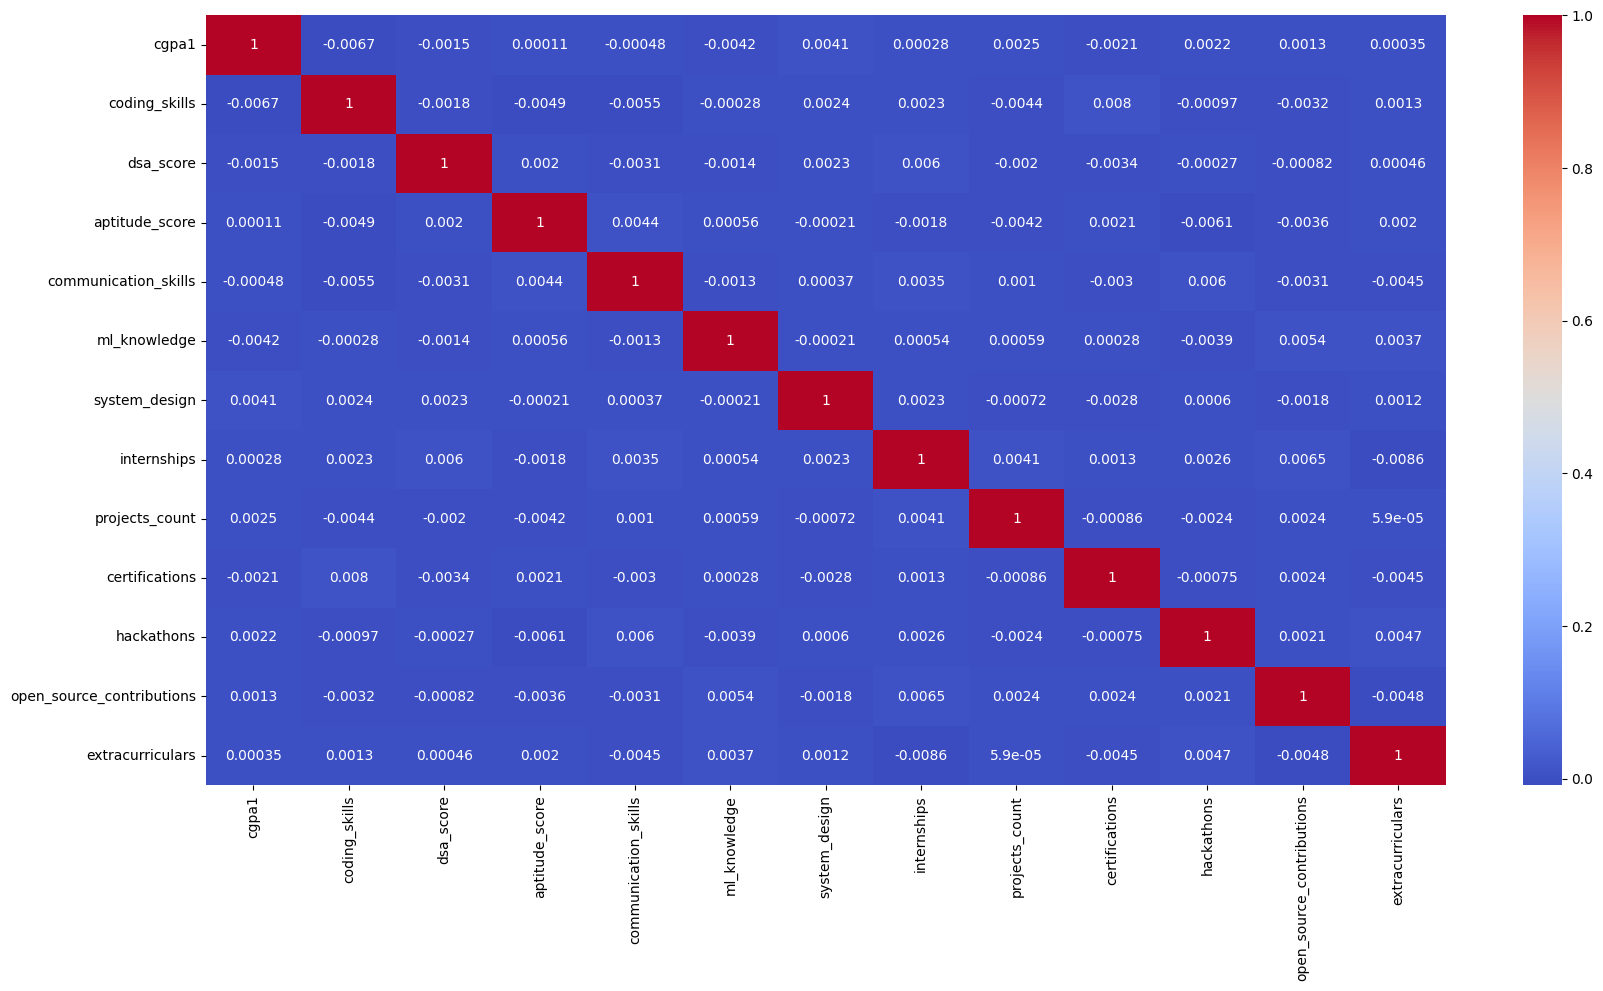

In [121]:
plt.figure(figsize = (20,10))
sns.heatmap(df1.corr(), annot=True, cmap="coolwarm")

In [40]:
categorical_columns


Index(['branch', 'college_tier'], dtype='object')

In [39]:
numeric_columns

Index(['cgpa', 'backlogs', 'coding_skills', 'dsa_score', 'aptitude_score',
       'communication_skills', 'ml_knowledge', 'system_design', 'internships',
       'projects_count', 'certifications', 'hackathons',
       'open_source_contributions', 'extracurriculars'],
      dtype='object')

In [51]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

pre = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_columns),
        ("categorical", OneHotEncoder(), categorical_columns)
    ]
)

In [104]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

x_train, x_test, y_cal_train, y_cal_test = train_test_split(x, y_cal, train_size=0.8, random_state=42)

pipeline = Pipeline([
    ("pre", pre),
    ("logistic", LogisticRegression(class_weight="balanced")),
])

In [105]:
pipeline.fit(x_train, y_cal_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('logistic', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [106]:
y_pred = pipeline.predict(x_test)
y_pred

array([1, 1, 0, ..., 0, 1, 1], shape=(20000,))

In [125]:
from sklearn.metrics import accuracy_score
accuracy_score(y_cal_test, y_pred)

0.63175

In [124]:
from sklearn.metrics import classification_report

print(classification_report(y_cal_test, y_pred))

              precision    recall  f1-score   support

           0       0.44      0.65      0.53      6335
           1       0.79      0.62      0.70     13665

    accuracy                           0.63     20000
   macro avg       0.62      0.64      0.61     20000
weighted avg       0.68      0.63      0.64     20000



In [126]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_cal_test, y_pred)

0.6365282866517016